# Modeling microbiota-wide metabolism with MICOM

This notebook will accompany the second session of the 2020 ISB Microbiome Course.

In [1]:
output_dir = "/data/scratch/kvalem/projects/2024/diabetes_microbe/05-results/figures"

## Basic Installation

In [2]:
#!git clone https://github.com/gibbons-lab/isb_course_2020 materials
# %cd materials

In [3]:
#!pip install -q micom

# print("Done! 🎉 ")

## Enable QIIME 2 interactions

In [4]:
#!pip install -q numpy Cython
#!pip install -q biom-format

# print("Done! 🎉 ")

# MICOM
MICOM starts from a combined abundance/taxonomy table, which MICOM abbreviates to a taxonomy table. To see how those tables look we can import MICOM and look at an example table:


## Importing data from QIIME 2
Model database to use:  [AGORA database](https://pubmed.ncbi.nlm.nih.gov/27893703/), which is a curated database of more than 800 bacterial strains that commonly live in the human gut. 

Version database summarized on the genus rank which can be downloaded from [MICOM data repository](https://doi.org/10.5281/zenodo.3755182) 

In [5]:
#!wget -O agora103_genus.qza https://zenodo.org/record/3755182/files/agora103_genus.qza?download=1

In [2]:
from micom.qiime_formats import load_qiime_medium
import pandas as pd
from micom.workflows import build
from micom import Community
import pandas as pd
from micom.workflows import grow
import pickle
from micom.viz import *
from micom.viz import *
import numpy as np
import pandas as pd
from micom.measures import production_rates
from micom.viz import plot_association
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.backends.backend_pdf import PdfPages
from micom.taxonomy import qiime_to_micom

In [19]:

#tax = qiime_to_micom(
#    "/data/projects/2024/Effenberger-Diabetes/out/nf_core_ampliseq_vsearch/qiime2/input/table.qza",
#    "/data/projects/2024/Effenberger-Diabetes/out/nf_core_ampliseq_vsearch/qiime2/input/taxonomy.qza",
#    collapse_on="genus",
#)


tax = qiime_to_micom(
    "/data/scratch/kvalem/projects/2024/diabetes_microbe/01-tables/materials/table.qza",
    "/data/scratch/kvalem/projects/2024/diabetes_microbe/01-tables/materials/taxonomy.qza",
    collapse_on="genus",
)

In [20]:
metadata = pd.read_table(
    #"/data/scratch/kvalem/projects/2024/Effenberger-Diabetes/02-scripts/nf-core_ampliseq/metadata.tsv"
    "/data/scratch/kvalem/projects/2024/diabetes_microbe/01-tables/nf-core_ampliseq/metadata_new.tsv"
).rename(columns={"id": "sample_id"})

In [21]:
tax = pd.merge(tax, metadata, on="sample_id")

In [22]:
tax["genus"] = tax["genus"].replace("Escherichia-Shigella", "Escherichia")

In [23]:
tax["id"] = tax["id"].replace("Escherichia_Shigella", "Escherichia")

## Building community models

In [11]:
#manifest2 = build(
#    tax, "../../01-tables/materials/agora103_genus.qza", "models_3", solver="osqp", cutoff=0.0001, threads=2
#)

[09/02/25 12:58:23] WARNING  Found existing models for 4 samples. Will skip those. Delete the output    ]8;id=355571;file:///home/kvalem/.local/lib/python3.11/site-packages/micom/workflows/build.py\build.py]8;;\:]8;id=926528;file:///home/kvalem/.local/lib/python3.11/site-packages/micom/workflows/build.py#98\98]8;;\
                             folder if you would like me to rebuild them.                                          

Output()

[09/02/25 12:58:42] WARNING  Less than 50% of the abundance     ]8;id=5968;file:///home/kvalem/.local/lib/python3.11/site-packages/micom/community.py\community.py]8;;\:]8;id=882521;file:///home/kvalem/.local/lib/python3.11/site-packages/micom/community.py#229\229]8;;\
                             could be matched to the model                      
                             database. Model `s20011_0005` may                  
                             not be representative of the                       
                             sample                                             
[09/02/25 13:19:29] WARNING  Less than 50% of the abundance     ]8;id=972562;file:///home/kvalem/.local/lib/python3.11/site-packages/micom/community.py\community.py]8;;\:]8;id=505065;file:///home/kvalem/.local/lib/python3.11/site-packages/micom/community.py#229\229]8;;\
                             could be matched to the model                      
                             database. 

/home/kvalem/.local/lib/python3.11/site-packages/micom/workflows/build.py:115: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_reduce_group)


For different data a warning may pop up if less than 50% of the abundances can be matched to the database. If this happens, you can still continue, but be aware that such a sparse model may not accurately represent your sample. In lower-biomass 16S amplicon sequencing samples from stool, many reads can match to food components or to host mitochondria and these hits probably do not contribute much to bacterial community metabolism. These hits will be excluded from MICOM. 

We won't see any warnings here. So, we will go ahead for now. Let's also take a look what we got back from the `build` process.

In [24]:
manifest_2 = pd.read_csv("/data/scratch/kvalem/projects/2024/diabetes_microbe/02-scripts/materials/models_3/manifest.csv")

In [25]:
manifest_2.head()

,sample_id,sample_information,age,KHK1,KHK2,CA1,CA2,HbA1C (DCCT/NGSP)1,HbA1C (DCCT/NGSP)2,Glukose1,...,HbA1C_diff,Glukose_diff,BMI_diff,KHK_diff,CA_diff,file,found_taxa,total_taxa,found_fraction,found_abundance_fraction
0,s20011_0001,K1,56,nein,nein,nein,nein,5.1,5.2,99,...,increase,decrease,increase,absent,absent,s20011_0001.pickle,27.0,76.0,0.355263,0.785923
1,s20011_0002,PDM1,71,ja,ja,nein,nein,6.7,8.2,128,...,increase,decrease,increase,persistent,absent,s20011_0002.pickle,30.0,59.0,0.508475,0.784466
2,s20011_0003,PDM13,68,nein,ja,nein,nein,7.7,8.7,84,...,increase,increase,increase,onset,absent,s20011_0003.pickle,34.0,94.0,0.361702,0.885819
3,s20011_0004,DM1,50,ja,nein,nein,nein,7.4,6.8,111,...,decrease,increase,increase,resolved,absent,s20011_0004.pickle,27.0,76.0,0.355263,0.813091
4,s20011_0005,DM13,19,nein,nein,nein,nein,7.5,6.3,106,...,decrease,decrease,increase,absent,absent,s20011_0005.pickle,34.0,82.0,0.414634,0.492874


In [26]:
pdm_manifest = manifest_2[manifest_2['sample_information'].str.startswith("PDM")]

In [27]:
dm_manifest = manifest_2[manifest_2['sample_information'].str.startswith("DM")]

In [34]:
k_manifest = manifest_2[manifest_2['sample_information'].str.startswith("K")]

## Simulating growth

'average Western Diet' to each individual. [MICOM data repository](https://doi.org/10.5281/zenodo.3755182).

In [15]:
#!wget -O western_diet_gut.qza https://zenodo.org/record/3755182/files/western_diet_gut.qza?download=1

This is again a QIIME 2 artifact, which we can load into MICOM.

In [29]:
#medium = load_qiime_medium("western_diet_gut.qza")
medium = load_qiime_medium("/data/scratch/kvalem/projects/2024/diabetes_microbe/01-tables/materials/western_diet_gut.qza")
medium

,flux,dilution,metabolite,reaction
reaction,,,,
EX_fru_m,0.014899,0.100,fru_m,EX_fru_m
EX_glc_m,0.014899,0.100,glc_m,EX_glc_m
EX_gal_m,0.014899,0.100,gal_m,EX_gal_m
EX_man_m,0.014899,0.100,man_m,EX_man_m
EX_mnl_m,0.014899,0.100,mnl_m,EX_mnl_m
...,...,...,...,...
EX_glu_D_m,0.100000,0.100,glu_D_m,EX_glu_D_m
EX_gthrd_m,0.100000,0.100,gthrd_m,EX_gthrd_m
EX_h2_m,0.100000,0.100,h2_m,EX_h2_m


In [37]:
growth_results_k = grow(k_manifest, model_folder="models_3", medium=medium, tradeoff=0.3,strategy ="pFBA", threads=2,presolve=True)

Output()

In [37]:
growth_results_dpm = grow(pdm_manifest, model_folder="models_3", medium=medium, tradeoff=0.3,strategy ="pFBA", threads=2,presolve=True)

Output()

In [37]:
growth_results_dm = grow(dm_manifest, model_folder="models_3", medium=medium, tradeoff=0.3,strategy ="pFBA", threads=2,presolve=True)

Output()

In [ ]:
#from micom.workflows import tradeoff

#tradeoff_rates = tradeoff(manifest_2, model_folder="models", medium=medium, threads=2)
#tradeoff_rates.head()

Output()

In [38]:
#pickle.dump(growth_results_pdm, open("growth_k.pickle", "wb"))
#pickle.dump(growth_results_pdm, open("/data/scratch/kvalem/projects/2024/diabetes_microbe/01-tables/materials/growth_pdm.pickle", "wb"))

In [38]:
#pickle.dump(growth_results_dm, open("growth_k.pickle", "wb"))
#pickle.dump(growth_results_dm, open("/data/scratch/kvalem/projects/2024/diabetes_microbe/01-tables/materials/growth_dm.pickle", "wb"))

In [38]:
#pickle.dump(growth_results_k, open("growth_k.pickle", "wb"))
#pickle.dump(growth_results_k, open("/data/scratch/kvalem/projects/2024/diabetes_microbe/01-tables/materials/growth_k.pickle", "wb"))

In [66]:
growth_results_dm = pickle.load(open("/data/scratch/kvalem/projects/2024/diabetes_microbe/01-tables/materials/growth_dm.pickle", "rb"))

In [66]:
growth_results_pdm = pickle.load(open("/data/scratch/kvalem/projects/2024/diabetes_microbe/01-tables/materials/growth_pdm.pickle", "rb"))

In [66]:
growth_results_h = pickle.load(open("/data/scratch/kvalem/projects/2024/diabetes_microbe/01-tables/materials/growth_h.pickle", "rb"))

In [67]:
growth_results_dm.growth_rates.index.unique()

Index(['Akkermansia', 'Alistipes', 'Anaerostipes', 'Bacteroides',
       'Barnesiella', 'Bifidobacterium', 'Bilophila', 'Blautia',
       'Butyricicoccus', 'Butyrivibrio', 'Coprococcus', 'Dorea', 'Escherichia',
       'Faecalibacterium', 'Intestinibacter', 'Lachnoclostridium',
       'Lachnospira', 'Lactococcus', 'Odoribacter', 'Oxalobacter',
       'Parabacteroides', 'Parasutterella', 'Phascolarctobacterium',
       'Roseburia', 'Ruminococcus', 'Streptococcus', 'Subdoligranulum',
       'Butyricimonas', 'Collinsella', 'Coprobacillus', 'Desulfovibrio',
       'Dialister', 'Erysipelatoclostridium', 'Haemophilus', 'Holdemanella',
       'Marvinbryantia', 'Slackia', 'Veillonella', 'Anaerotruncus',
       'Paraprevotella', 'Pseudoflavonifractor', 'Acidaminococcus',
       'Adlercreutzia', 'Brachyspira', 'Eggerthella', 'Flavonifractor',
       'Gordonibacter', 'Holdemania', 'Methanosphaera', 'Oribacterium',
       'Sutterella', 'Anaerofustis', 'Enterococcus', 'Lactobacillus',
       'Tyzzer

Exchange fluxes.

- How much of each metabolite is either consumed or produced by each taxon in each sample. 
- Tolerance denotes the accuracy of the solver and tells you the smallest absolute flux that is likely different form zero (i.e. substantial flux).
- *All of the fluxes are normalized to 1g dry weight of bacteria*. So, you can directly compare fluxes between taxa, even if they are present at very different abundances. 


In [68]:
anns = growth_results_dm.annotations

In [88]:
#from micom.interaction import interactions

#ints = interactions(growth_results, taxa="Escherichia")
#ints.sort_values(by="flux", ascending=False).head()

In [89]:
#from micom.interaction import summarize_interactions

#summary = summarize_interactions(ints)
#summary.head()

In [90]:
#full = interactions(growth_results, taxa=None, threads=8)
#full.shape

In [91]:
#full.head()

In [92]:
#full_summary = summarize_interactions(full)
#full_summary.shape

In [93]:
#full_summary.head()

In [70]:
viz = plot_growth(growth_results_dm,filename="t1dm_growth_rates.html")

In [70]:
viz = plot_growth(growth_results_pdm,filename="t3cdm_growth_rates.html")

In [70]:
viz = plot_growth(growth_results_h,filename="h_growth_rates.html")

In [71]:
viz

In [ ]:
#results 
#"/data/scratch/kvalem/projects/2024/diabetes_microbe/01-tables/growth_rates_20250624.html"

## Growth niches

1. What dietary nutrients are consumed by the microbiota `plot_exchanges_per_sample`
2. What metabolites do the microbiota produce?' 

In [72]:
plot_exchanges_per_sample(growth_results_dm,filename="t1dm_exchanges_per_sample.html" )

In [72]:
plot_exchanges_per_sample(growth_results_pdm,filename="t3cdm_exchanges_per_sample.html" )

In [72]:
plot_exchanges_per_sample(growth_results_h,filename="healthy_exchanges_per_sample.html" )

In [73]:
plot_exchanges_per_taxon(growth_results_dm, perplexity=4, direction="import",filename="t1dm_exchanges_per_taxon.html" )

In [73]:
plot_exchanges_per_taxon(growth_results_pdm, perplexity=4, direction="import",filename="t3cdm_exchanges_per_taxon.html" )

In [73]:
plot_exchanges_per_taxon(growth_results_h, perplexity=4, direction="import",filename="healthy_exchanges_per_taxon.html" )

In [34]:
#results 
#"/data/scratch/kvalem/projects/2024/diabetes_microbe/01-tables/taxon_exchanges_20250624.html"

In [ ]:
exchanges = growth_results.exchanges
exchanges = pd.merge(exchanges, metadata, on="sample_id")

In [42]:
def assign_condition(info):
    if "PDM" in info:
        return "T3cDM"
    elif "K" in info:
        return "H"
    else:
        return "T1DM"

exchanges['condition'] = exchanges['sample_information'].apply(assign_condition)

In [44]:
#exchanges.to_csv("/data/scratch/kvalem/projects/2024/diabetes_microbe/01-tables/materials/exchange_fluxes_k.csv", sep = "\t")

### Plotting flux

In [107]:
#exchange_fluxes = pd.read_csv("./tmp_results/exchange_fluxes.csv")
#exchange_fluxes = pd.read_csv("/data/scratch/kvalem/projects/2024/diabetes_microbe/01-tables/materials/exchange_fluxes_pdm.csv", sep = "\t")

In [44]:
filtered_df = exchanges

In [ ]:
filtered_df['flux'] = pd.to_numeric(filtered_df['flux'], errors='coerce')
filtered_df['abundance'] = pd.to_numeric(filtered_df['abundance'], errors='coerce')

h2s_df = filtered_df[filtered_df['metabolite'] == 'h2s[e]'].copy()

barplot_data = (
    h2s_df
    .groupby(['taxon', 'condition'])['flux']
    .mean()
    .reset_index()
)

taxon_order = (
    barplot_data.groupby('taxon')['flux']
    .sum()
    .sort_values()
    .index
)

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(
    data=barplot_data,
    y='taxon',
    x='flux',
    hue='condition',
    order=taxon_order
)
plt.title("Flux of h2s[e] by Taxon and Condition")
plt.xlabel("Mean Flux")
plt.ylabel("Taxon")
plt.tight_layout()
plt.show()

In [ ]:
import itertools

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy.stats import ttest_ind

metabolites_of_interest = significant_metabolites


conditions = exchanges["condition"].unique().tolist()
comparisons = list(itertools.combinations(conditions, 2))

n_cols = 3
n_rows = (len(metabolites_of_interest) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 6, n_rows * 5))
axes = axes.flatten()

for i, metabolite in enumerate(metabolites_of_interest):
    ax = axes[i]
    df = exchanges[exchanges["description"] == metabolite]

    if df.empty:
        ax.set_visible(False)
        continue

    
    sns.boxplot(data=df, x="condition", y="flux", ax=ax, showcaps=True,
                boxprops={'facecolor': 'None'}, showfliers=False,
                whiskerprops={'linewidth': 2}, medianprops={'color': 'black'})
    
    sns.swarmplot(data=df, x="condition", y="flux", ax=ax, color=".25", size=4)

    
    y_max = df["flux"].max()
    y_start = y_max * 1.05
    h = y_max * 0.05

    for j, (cond1, cond2) in enumerate(comparisons):
        group1 = df[df["condition"] == cond1]["flux"]
        group2 = df[df["condition"] == cond2]["flux"]

        if group1.empty or group2.empty:
            continue

        stat, pval = ttest_ind(group1, group2)
        x1 = conditions.index(cond1)
        x2 = conditions.index(cond2)
        y = y_start + j * h * 1.5
        ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], lw=1.2, c='black')
        ax.text((x1 + x2) / 2, y + h * 1.05, f"p = {pval:.3e}", ha='center', va='bottom', fontsize=8)

    ax.set_title(metabolite, fontsize=10)
    ax.set_xlabel("")
    ax.set_ylabel("Flux", fontsize=9)
    ax.tick_params(axis='x', rotation=45)


for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

pdf_path = "metabolite_flux_comparison_plots.pdf"

pdf.savefig(fig)#

print(f"PDF saved to: {pdf_path}")

In [ ]:
exchange_fluxes_female = exchange_fluxes[exchange_fluxes["AH"] == "yes"]

In [ ]:
heatmap_data = exchange_fluxes_female.pivot_table(
    index="description",  
    columns="sample_information", 
    values="flux", 
    aggfunc="mean", 
)

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy.stats import zscore

flux_matrix = exchange_fluxes_female.pivot_table(
    index="description", columns="sample_information", values="flux", aggfunc="mean"
)

flux_z = flux_matrix.apply(zscore, axis=1, nan_policy="omit")
flux_z = flux_z.dropna(how="all")

plt.figure(figsize=(12, 8))
sns.heatmap(flux_z, cmap="Spectral_r", center=0, linewidths=0.5, linecolor="gray")
plt.title("Z-scored Flux Heatmap by Sample")
plt.xlabel("Sample Information")
plt.ylabel("Metabolite")
plt.tight_layout()
plt.show()

### Plotting growth rate

In [48]:
# Loading csv from "/data/scratch/kvalem/projects/2024/diabetes_microbe/01-tables/taxon_exchanges_20250624.html"

#growth_rates = pd.read_csv("growth_rates.csv")
#growth_rates = pd.read_csv("/data/scratch/kvalem/projects/2024/diabetes_microbe/01-tables/materials/growth_rates.csv")

In [12]:
growth_rates_healhty = pd.read_csv("/data/scratch/kvalem/projects/2024/diabetes_microbe/02-scripts/materials/escherichia/growth_rates_healthy.csv")

In [13]:
growth_rates_healhty['condition']="H"

In [6]:
growth_rates_t1dm = pd.read_csv("/data/scratch/kvalem/projects/2024/diabetes_microbe/02-scripts/materials/escherichia/growth_rates_t1dm.csv")

In [7]:
growth_rates_t1dm['condition']="T1DM"

In [8]:
growth_rates_t3cdm = pd.read_csv("/data/scratch/kvalem/projects/2024/diabetes_microbe/02-scripts/materials/escherichia/growth_rates_t3cdm.csv")

In [9]:
growth_rates_t3cdm['condition']="T3cDM"

In [16]:
growth_rates = pd.concat(
    [growth_rates_healhty, growth_rates_t1dm, growth_rates_t3cdm],
    axis=0  # row-wise concatenation (default)
)

In [52]:
def assign_condition(info):
    if "PDM" in info:
        return "T3cDM"
    elif "K" in info:
        return "H"
    else:
        return "T1DM"

growth_rates['condition'] = growth_rates['sample_information'].apply(assign_condition)

In [ ]:
growth_rates = pd.merge(growth_rates, metadata, on="sample_id")

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy.stats import zscore

growth_matrix = growth_rates.pivot_table(
    index="taxon",
    columns="sample_information",
    values="growth_rate",
    aggfunc="mean", 
)

growth_z = growth_matrix.apply(zscore, axis=1, nan_policy="omit")

growth_z = growth_z.dropna(how="all")


plt.figure(figsize=(10, 8))
sns.heatmap(
    growth_z,
    cmap="viridis",  
    center=0,
    linewidths=0.5,
    linecolor="gray",
)
plt.title("Z-scored Growth Rate per Taxon Across Samples")
plt.xlabel("Sample Information")
plt.ylabel("Taxon")
plt.tight_layout()
plt.show()

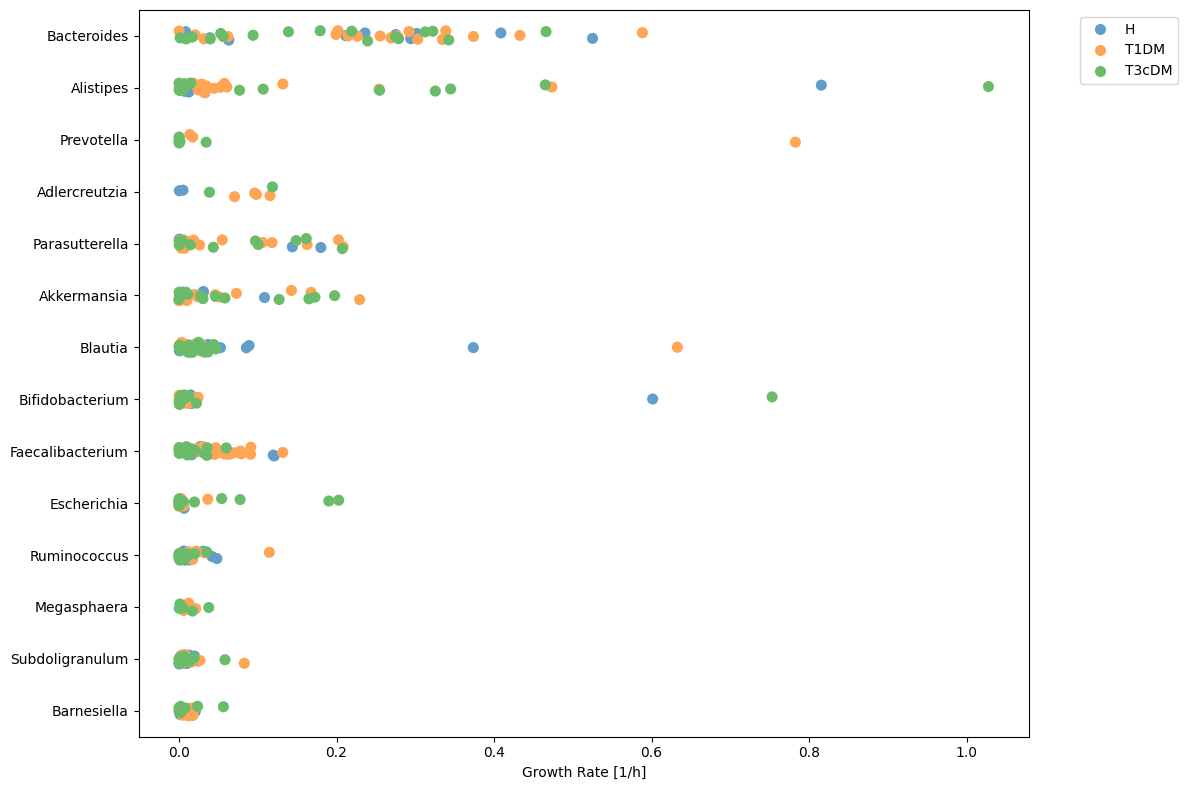

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

my_palette = {
    "T3cDM": "#6ABC6A",  
    "T1DM": "#FFA555",  
    "H": "#619FCA"      
}
taxa_top20 = (
    growth_rates.groupby('taxon', as_index=False)['growth_rate']
    .mean()
    .nlargest(20, 'growth_rate')['taxon']
)

# 2) Keep all rows belonging to those taxa (to show per-sample dots)
plot_df = growth_rates[growth_rates['taxon'].isin(taxa_top20)]
plot_df = (
    plot_df
    .groupby("taxon")
    .filter(lambda x: len(x) >= 5)
)
order = (
    plot_df.groupby('taxon')['growth_rate']
    .mean()
    .sort_values(ascending=False)
    .index
)
plt.figure(figsize=(12, 8))
sns.stripplot(
    data=plot_df,
    x="growth_rate",
    y="taxon",order = order,
    hue="condition",
    jitter=True,
    dodge=False,
    size=8,
    alpha=1 ,   palette=my_palette 
)

plt.title("")
plt.xlabel("Growth Rate [1/h]")
plt.ylabel("")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", title="")
plt.tight_layout()
output_dir = "/data/scratch/kvalem/projects/2024/diabetes_microbe/05-results/figures"
plt.savefig(f"{output_dir}/growth_rate_by_taxon.png", format="png", dpi=300, bbox_inches="tight")
plt.savefig(f"{output_dir}/growth_rate_by_taxon.svg", format="svg", bbox_inches="tight")

plt.show()

### Plotting growth rate

In [149]:
# Loading csv from "/data/scratch/kvalem/projects/2024/diabetes_microbe/01-tables/taxon_exchanges_20250624.html"
#reduced = pd.read_csv("/data/scratch/kvalem/projects/2024/diabetes_microbe/01-tables/materials/reduced.csv")

In [150]:
# Loading csv from "/data/scratch/kvalem/projects/2024/diabetes_microbe/01-tables/taxon_exchanges_20250624.html"
reduced_h = pd.read_csv("/data/scratch/kvalem/projects/2024/diabetes_microbe/02-scripts/materials/escherichia/reduced_h.csv")

In [151]:
# Loading csv from "/data/scratch/kvalem/projects/2024/diabetes_microbe/01-tables/taxon_exchanges_20250624.html"
reduced_t1dm = pd.read_csv("/data/scratch/kvalem/projects/2024/diabetes_microbe/02-scripts/materials/escherichia/reduced_t1dm.csv")

In [152]:
# Loading csv from "/data/scratch/kvalem/projects/2024/diabetes_microbe/01-tables/taxon_exchanges_20250624.html"
reduced_t3cdm = pd.read_csv("/data/scratch/kvalem/projects/2024/diabetes_microbe/02-scripts/materials/escherichia/reduced_t3cdm.csv")

In [153]:
reduced_h['condition']="H"
reduced_t1dm['condition']="T1DM"
reduced_t3cdm['condition']="T3cDM"

In [154]:
reduced = pd.concat(
    [reduced_h, reduced_t1dm, reduced_t3cdm],
    axis=0  # row-wise concatenation (default)
)

In [155]:
reduced

,sample_id,taxon,TSNE 1,TSNE 2,condition
0,s20011_0001,Akkermansia,-6.646024,-7.329967,H
1,s20011_0001,Anaerostipes,-4.459616,18.260870,H
2,s20011_0001,Anaerotruncus,57.763218,14.070005,H
3,s20011_0001,Bacteroides,-36.644543,9.407182,H
4,s20011_0001,Bifidobacterium,35.365025,11.878210,H
...,...,...,...,...,...
529,s20011_0048,Ruminococcus,14.872862,-69.736010,T3cDM
530,s20011_0048,Slackia,34.503033,-15.718627,T3cDM
531,s20011_0048,Streptococcus,19.081417,-74.211930,T3cDM
532,s20011_0048,Subdoligranulum,8.505709,49.109116,T3cDM


In [156]:
reduced = pd.merge(reduced, metadata, on="sample_id")
reduced

,sample_id,taxon,TSNE 1,TSNE 2,condition,sample_information,age,KHK1,KHK2,CA1,...,Glukose1,Glukose2,BMI1,BMI2,Pankreatektomie,HbA1C_diff,Glukose_diff,BMI_diff,KHK_diff,CA_diff
0,s20011_0001,Akkermansia,-6.646024,-7.329967,H,K1,56,nein,nein,nein,...,99,89.0,23.9,24.1,nein,increase,decrease,increase,absent,absent
1,s20011_0001,Anaerostipes,-4.459616,18.260870,H,K1,56,nein,nein,nein,...,99,89.0,23.9,24.1,nein,increase,decrease,increase,absent,absent
2,s20011_0001,Anaerotruncus,57.763218,14.070005,H,K1,56,nein,nein,nein,...,99,89.0,23.9,24.1,nein,increase,decrease,increase,absent,absent
3,s20011_0001,Bacteroides,-36.644543,9.407182,H,K1,56,nein,nein,nein,...,99,89.0,23.9,24.1,nein,increase,decrease,increase,absent,absent
4,s20011_0001,Bifidobacterium,35.365025,11.878210,H,K1,56,nein,nein,nein,...,99,89.0,23.9,24.1,nein,increase,decrease,increase,absent,absent
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1512,s20011_0048,Ruminococcus,14.872862,-69.736010,T3cDM,PDM12,75,ja,nein,ja,...,92,303.0,22.6,24.9,Teilresektion rechts,increase,increase,increase,resolved,persistent
1513,s20011_0048,Slackia,34.503033,-15.718627,T3cDM,PDM12,75,ja,nein,ja,...,92,303.0,22.6,24.9,Teilresektion rechts,increase,increase,increase,resolved,persistent
1514,s20011_0048,Streptococcus,19.081417,-74.211930,T3cDM,PDM12,75,ja,nein,ja,...,92,303.0,22.6,24.9,Teilresektion rechts,increase,increase,increase,resolved,persistent
1515,s20011_0048,Subdoligranulum,8.505709,49.109116,T3cDM,PDM12,75,ja,nein,ja,...,92,303.0,22.6,24.9,Teilresektion rechts,increase,increase,increase,resolved,persistent


In [157]:
# List of target taxa
target_taxa = [
    'Akkermansia', 'Blautia', 'Escherichia', 'Faecalibacterium',
    'Streptococcus', 'Subdoligranulum'
]

# Filter the DataFrame
reduced = reduced[reduced['taxon'].isin(target_taxa)]


In [158]:
reduced

,sample_id,taxon,TSNE 1,TSNE 2,condition,sample_information,age,KHK1,KHK2,CA1,...,Glukose1,Glukose2,BMI1,BMI2,Pankreatektomie,HbA1C_diff,Glukose_diff,BMI_diff,KHK_diff,CA_diff
0,s20011_0001,Akkermansia,-6.646024,-7.329967,H,K1,56,nein,nein,nein,...,99,89.0,23.9,24.1,nein,increase,decrease,increase,absent,absent
5,s20011_0001,Blautia,-23.906338,-9.794666,H,K1,56,nein,nein,nein,...,99,89.0,23.9,24.1,nein,increase,decrease,increase,absent,absent
11,s20011_0001,Escherichia,37.393177,-2.836009,H,K1,56,nein,nein,nein,...,99,89.0,23.9,24.1,nein,increase,decrease,increase,absent,absent
12,s20011_0001,Faecalibacterium,-58.816360,-2.522330,H,K1,56,nein,nein,nein,...,99,89.0,23.9,24.1,nein,increase,decrease,increase,absent,absent
24,s20011_0001,Streptococcus,-4.300920,61.022507,H,K1,56,nein,nein,nein,...,99,89.0,23.9,24.1,nein,increase,decrease,increase,absent,absent
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1491,s20011_0048,Blautia,-5.187688,72.519110,T3cDM,PDM12,75,ja,nein,ja,...,92,303.0,22.6,24.9,Teilresektion rechts,increase,increase,increase,resolved,persistent
1500,s20011_0048,Escherichia,-14.273064,42.764927,T3cDM,PDM12,75,ja,nein,ja,...,92,303.0,22.6,24.9,Teilresektion rechts,increase,increase,increase,resolved,persistent
1501,s20011_0048,Faecalibacterium,18.797020,-68.119000,T3cDM,PDM12,75,ja,nein,ja,...,92,303.0,22.6,24.9,Teilresektion rechts,increase,increase,increase,resolved,persistent
1514,s20011_0048,Streptococcus,19.081417,-74.211930,T3cDM,PDM12,75,ja,nein,ja,...,92,303.0,22.6,24.9,Teilresektion rechts,increase,increase,increase,resolved,persistent


In [159]:
def assign_condition(info):
    if "PDM" in info:
        return "T3cDM"
    elif "K" in info:
        return "H"
    else:
        return "T1DM"

reduced['condition'] = reduced['sample_information'].apply(assign_condition)

/tmp/ipykernel_674404/2273843439.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  reduced['condition'] = reduced['sample_information'].apply(assign_condition)


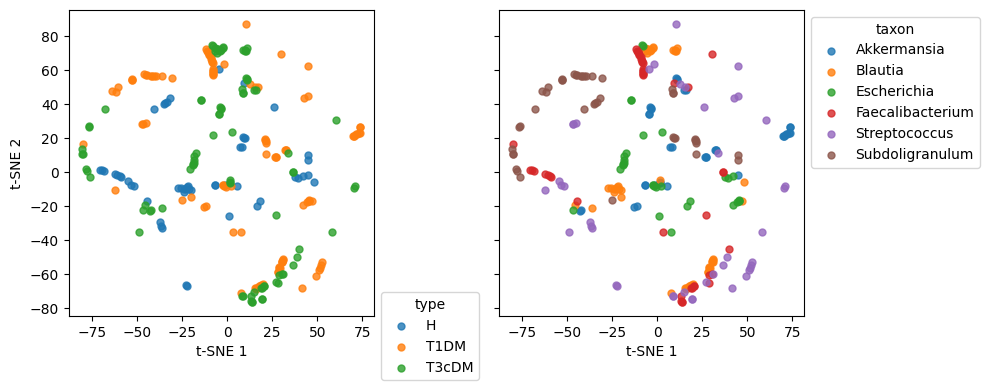

In [160]:
import matplotlib.pyplot as plt

# Step 1: Create subplots
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)

for cond, group in reduced.groupby("taxon"):
    axes[1].scatter(group["TSNE 1"], group["TSNE 2"], label=cond, alpha=0.8, s=25)
axes[1].set_title("")
axes[1].set_xlabel("t-SNE 1")
axes[1].legend(title="taxon", bbox_to_anchor=(1, 1), loc="upper left")

# Step 2: Plot colored by taxon
for taxon, group in reduced.groupby("condition"):
    axes[0].scatter(group["TSNE 1"], group["TSNE 2"], label=taxon, alpha=0.8, s=25)
axes[0].set_title("")
axes[0].set_xlabel("t-SNE 1")
axes[0].set_ylabel("t-SNE 2")
axes[0].legend(title="type", bbox_to_anchor=(1, 0.1), loc="upper left")

# Step 3: Plot colored by condition


plt.tight_layout()

plt.savefig(f"{output_dir}/tsne_metabolism_flux.png", format="png", dpi=300, bbox_inches="tight")
plt.savefig(f"{output_dir}/tsne_metabolism_flux.svg", format="svg", dpi=300, bbox_inches="tight")
plt.show()